<a href="https://colab.research.google.com/github/Dimitrispap123/Alzheimer-Web-Crawling/blob/main/team6_alzorg_crawler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Web Content Mining — Εργασία Β (Α Μέρος)
## Ομάδα 6 — Alzheimer's Association USA
**Base URL:** https://www.alz.org  
**Στάδια:** 1 (Συλλογή), 2 (Αποθήκευση), 3 (Preprocessing A)

In [ ]:
# ── Cell 1: Εγκατάσταση βιβλιοθηκών ─────────────────────────────────
import subprocess, sys

packages = [
    'requests',
    'beautifulsoup4',
    'lxml',
    'pandas',
    'tqdm',
    'matplotlib',
    'seaborn'
]

for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    status = '✓' if result.returncode == 0 else '✗'
    print(f'{status} {pkg}')

print('\n✅ Εγκατάσταση ολοκληρώθηκε!')

✓ requests
✓ beautifulsoup4
✓ lxml
✓ pandas
✓ tqdm
✓ matplotlib
✓ seaborn

✅ Εγκατάσταση ολοκληρώθηκε!


In [ ]:
# ── Cell 2: Imports ───────────────────────────────────────────────────
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
import os
import csv
from urllib.parse import urljoin, urlparse, urldefrag
from collections import deque
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Όλες οι βιβλιοθήκες φορτώθηκαν επιτυχώς.')

✅ Όλες οι βιβλιοθήκες φορτώθηκαν επιτυχώς.


In [ ]:
# ── Cell 3: Configuration ─────────────────────────────────────────────
BASE_URL = 'https://www.alz.org'

SEED_URLS = [
    'https://www.alz.org/',
    'https://www.alz.org/alzheimers-dementia/what-is-alzheimers',
    'https://www.alz.org/alzheimers-dementia/what-is-dementia',
    'https://www.alz.org/alzheimers-dementia/diagnosis',
    'https://www.alz.org/alzheimers-dementia/stages',
    'https://www.alz.org/alzheimers-dementia/treatments-research',
    'https://www.alz.org/alzheimers-dementia/facts-figures',
    'https://www.alz.org/research',
    'https://www.alz.org/alzheimers-dementia/what-is-alzheimers/causes-and-risk-factors',
    'https://www.alz.org/alzheimers-dementia/what-is-alzheimers/younger-early-onset',
    'https://www.alz.org/alzheimers-dementia/what-is-alzheimers/genes',
    'https://www.alz.org/alzheimers-dementia/what-is-alzheimers/brain-tour',
    'https://www.alz.org/alzheimers-dementia/what-is-alzheimers/related-conditions',
    'https://www.alz.org/alzheimers-dementia/diagnosis/symptoms',
    'https://www.alz.org/alzheimers-dementia/diagnosis/medical-tests',
    'https://www.alz.org/alzheimers-dementia/treatments/medications-for-memory',
    'https://www.alz.org/alzheimers-dementia/treatments/aducanumab',
    'https://www.alz.org/alzheimers-dementia/treatments/lecanemab',
    'https://www.alz.org/help-support/caregiving',
    'https://www.alz.org/help-support/caregiving/stages-behaviors',
    'https://www.alz.org/help-support/caregiving/financial-legal-planning',
    'https://www.alz.org/help-support/caregiving/safety',
    'https://www.alz.org/help-support/resources',
    'https://www.alz.org/help-support/i-have-alz',
    'https://www.alz.org/help-support/i-have-alz/know-the-10-signs',
    'https://www.alz.org/research/science/alzheimers-dementia-research',
    'https://www.alz.org/research/science/major-milestones-in-alzheimers-research',
    'https://www.alz.org/research/science/earlier-diagnosis',
    'https://www.alz.org/research/science/prevention',
    'https://www.alz.org/research/for-researchers',
    'https://www.alz.org/about',
    'https://www.alz.org/news',
    'https://www.alz.org/professionals/public-health',
]

REQUEST_DELAY = 1.5   # δευτερόλεπτα αναμονής μεταξύ αιτημάτων
MAX_PAGES     = None  # None = crawl ολόκληρου του ιστοτόπου

HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    ),
    'Accept-Language': 'en-US,en;q=0.9',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
}

print(f'BASE_URL      : {BASE_URL}')
print(f'Seed URLs     : {len(SEED_URLS)}')
print(f'Request delay : {REQUEST_DELAY}s')
print(f'Max pages     : {MAX_PAGES if MAX_PAGES else "Χωρίς όριο"}')

BASE_URL      : https://www.alz.org
Seed URLs     : 33
Request delay : 1.5s
Max pages     : Χωρίς όριο


In [ ]:
# ── Cell 4: Helper Functions ──────────────────────────────────────────

# Επεκτάσεις αρχείων που δεν μας ενδιαφέρουν (εκτός PDF/DOC)
SKIP_EXTENSIONS = (
    '.jpg', '.jpeg', '.png', '.gif', '.webp', '.svg',
    '.xlsx', '.pptx', '.zip', '.mp4', '.mp3', '.mov', '.avi',
    '.css', '.js', '.ico', '.woff', '.woff2', '.ttf', '.eot'
)

def is_internal(url: str) -> bool:
    """Ελέγχει αν το URL ανήκει στον ίδιο domain."""
    parsed = urlparse(url)
    base   = urlparse(BASE_URL)
    return parsed.netloc == base.netloc or parsed.netloc == ''


def clean_url(url: str) -> str:
    """Αφαιρεί fragment (#...) και trailing slash για consistency."""
    url, _ = urldefrag(url)          # αφαιρεί #anchor
    url = url.rstrip('/')            # αφαιρεί trailing slash
    return url


def should_skip(url: str) -> bool:
    """True αν το URL πρέπει να παραλειφθεί."""
    parsed_path = urlparse(url).path.lower()
    # Παρακάμπτει μη-HTML επεκτάσεις (εκτός .pdf/.doc/.docx)
    for ext in SKIP_EXTENSIONS:
        if parsed_path.endswith(ext):
            return True
    return False


def extract_text(soup: BeautifulSoup) -> str:
    """Εξάγει το κυρίως κείμενο της σελίδας, αφαιρώντας nav/header/footer."""
    # Αφαίρεση non-content tags
    for tag in soup(['script', 'style', 'nav', 'header', 'footer',
                     'aside', 'noscript', 'form', 'button', 'svg']):
        tag.decompose()

    # Προσπάθεια να βρούμε το κυρίως <main> ή <article>
    main = soup.find('main') or soup.find('article') or soup.find('div', {'id': 'content'})
    target = main if main else soup.body if soup.body else soup

    text = target.get_text(separator=' ', strip=True)
    # Καθαρισμός extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def extract_links(soup: BeautifulSoup, current_url: str) -> list:
    """Εξάγει όλα τα εσωτερικά links από τη σελίδα."""
    links = []
    for a_tag in soup.find_all('a', href=True):
        href = a_tag['href'].strip()
        # Μετατροπή σχετικών URLs σε απόλυτα
        full_url = urljoin(current_url, href)
        full_url = clean_url(full_url)
        if is_internal(full_url) and not should_skip(full_url):
            links.append(full_url)
    return links


def fetch_page(url: str, session: requests.Session) -> BeautifulSoup | None:
    """Κατεβάζει μια σελίδα και επιστρέφει BeautifulSoup object ή None."""
    try:
        resp = session.get(url, timeout=15, allow_redirects=True)
        if resp.status_code == 200:
            content_type = resp.headers.get('Content-Type', '')
            if 'text/html' in content_type:
                return BeautifulSoup(resp.text, 'lxml')
        return None
    except Exception:
        return None


print('✅ Helper functions ορίστηκαν επιτυχώς.')

✅ Helper functions ορίστηκαν επιτυχώς.


In [ ]:
# ── Cell 5: Crawler Loop ──────────────────────────────────────────────
import time as _time

session = requests.Session()
session.headers.update(HEADERS)

visited   = set()
queue     = deque()
records   = []

# Αρχικοποίηση ουράς με seed URLs
for url in SEED_URLS:
    cleaned = clean_url(url)
    queue.append(cleaned)
    visited.add(cleaned)

start_time = _time.time()

# Progress bar — χωρίς συγκεκριμένο total γιατί MAX_PAGES=None
pbar = tqdm(desc='🔍 Crawling alz.org', unit=' pages')

while queue:
    # Έλεγχος ορίου σελίδων
    if MAX_PAGES and len(records) >= MAX_PAGES:
        break

    current_url = queue.popleft()
    soup = fetch_page(current_url, session)

    if soup is None:
        pbar.set_postfix({'last': current_url[-50:], 'status': 'SKIP'})
        time.sleep(REQUEST_DELAY)
        continue

    # Εξαγωγή δεδομένων
    title      = soup.title.get_text(strip=True) if soup.title else ''
    text       = extract_text(soup)
    word_count = len(text.split())
    char_count = len(text)

    records.append({
        'url':        current_url,
        'title':      title,
        'word_count': word_count,
        'char_count': char_count,
        'text':       text
    })

    # Ανακάλυψη νέων links
    new_links = extract_links(soup, current_url)
    for link in new_links:
        if link not in visited:
            visited.add(link)
            queue.append(link)

    pbar.update(1)
    pbar.set_postfix({
        'pages':   len(records),
        'queue':   len(queue),
        'last':    current_url[-40:]
    })

    time.sleep(REQUEST_DELAY)

pbar.close()
elapsed = _time.time() - start_time

print(f'\n✅ Crawling ολοκληρώθηκε!')
print(f'   Σελίδες που συλλέχθηκαν : {len(records)}')
print(f'   Χρόνος εκτέλεσης        : {elapsed/60:.1f} λεπτά ({elapsed:.0f} δευτ.)')

🔍 Crawling alz.org: 0 pages [00:00, ? pages/s]


✅ Crawling ολοκληρώθηκε!
   Σελίδες που συλλέχθηκαν : 4539
   Χρόνος εκτέλεσης        : 182.8 λεπτά (10970 δευτ.)


💾 raw_data.csv αποθηκεύτηκε.

📊 Στατιστικά Raw Corpus (πριν τον καθαρισμό):
                       Μετρική Αποτέλεσμα
             Συνολικές σελίδες      4,539
              Συνολικές λέξεις  3,664,401
          Συνολικοί χαρακτήρες 24,004,316
    Μέσος όρος λέξεων / σελίδα      807.3
Μέσος όρος χαρακτήρων / σελίδα    5,288.5
      Χρόνος εκτέλεσης (λεπτά)      182.8


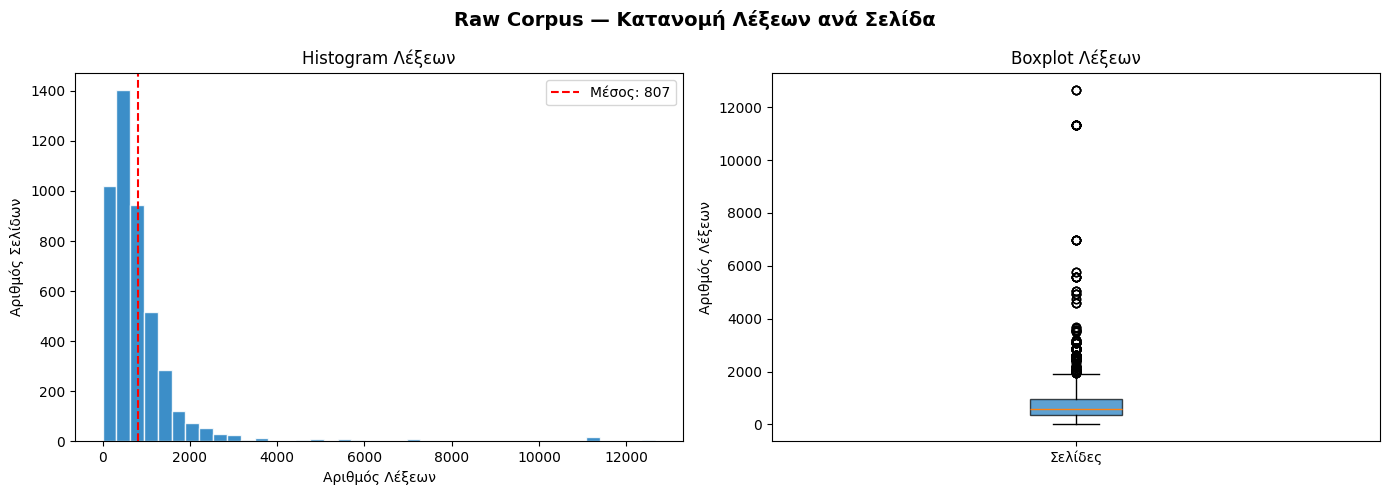

📈 Γράφημα αποθηκεύτηκε: chart_raw_wordcount.png


In [ ]:
# ── Cell 6: Στατιστικά Raw Corpus & Αποθήκευση ───────────────────────

# Δημιουργία DataFrame
raw_df = pd.DataFrame(records)

# ── Αποθήκευση raw_data.csv ──
raw_df.to_csv('raw_data.csv', index=False, encoding='utf-8-sig')
print('💾 raw_data.csv αποθηκεύτηκε.')

# ── Υπολογισμός Στατιστικών ──
total_pages    = len(raw_df)
total_words    = raw_df['word_count'].sum()
total_chars    = raw_df['char_count'].sum()
avg_words_page = raw_df['word_count'].mean()
avg_chars_page = raw_df['char_count'].mean()

stats_raw = pd.DataFrame({
    'Μετρική': [
        'Συνολικές σελίδες',
        'Συνολικές λέξεις',
        'Συνολικοί χαρακτήρες',
        'Μέσος όρος λέξεων / σελίδα',
        'Μέσος όρος χαρακτήρων / σελίδα',
        'Χρόνος εκτέλεσης (λεπτά)'
    ],
    'Αποτέλεσμα': [
        f'{total_pages:,}',
        f'{total_words:,}',
        f'{total_chars:,}',
        f'{avg_words_page:,.1f}',
        f'{avg_chars_page:,.1f}',
        f'{elapsed/60:.1f}'
    ]
})

print('\n📊 Στατιστικά Raw Corpus (πριν τον καθαρισμό):')
print(stats_raw.to_string(index=False))

# ── Γράφημα: Κατανομή Λέξεων στο Raw Corpus ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Raw Corpus — Κατανομή Λέξεων ανά Σελίδα', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(raw_df['word_count'], bins=40, color='#1a7abf', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Αριθμός Λέξεων')
axes[0].set_ylabel('Αριθμός Σελίδων')
axes[0].set_title('Histogram Λέξεων')
axes[0].axvline(avg_words_page, color='red', linestyle='--', label=f'Μέσος: {avg_words_page:.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(raw_df['word_count'], patch_artist=True,
                boxprops=dict(facecolor='#1a7abf', alpha=0.7))
axes[1].set_ylabel('Αριθμός Λέξεων')
axes[1].set_title('Boxplot Λέξεων')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Σελίδες'])

plt.tight_layout()
plt.savefig('chart_raw_wordcount.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Γράφημα αποθηκεύτηκε: chart_raw_wordcount.png')

In [ ]:
# ── Cell 7: Preprocessing A — Καθαρισμός URL / Page Level ────────────

# Κανόνες καθαρισμού
IMAGE_EXTS     = ('.jpg', '.jpeg', '.png', '.gif', '.webp', '.svg')
MEDIA_EXTS     = ('.mp4', '.mp3', '.mov', '.avi', '.xlsx', '.pptx', '.zip')
WP_UPLOAD_PAT  = re.compile(r'/wp-content/uploads/', re.IGNORECASE)
TAG_PAT        = re.compile(r'/(news-tag|tag|category)/', re.IGNORECASE)
PAGE_NUM_PAT   = re.compile(r'/page/\d+/', re.IGNORECASE)
KEEP_EXTS      = ('.pdf', '.doc', '.docx')  # διατηρούνται

def classify_removal(url: str):
    """Επιστρέφει τον λόγο αφαίρεσης ή None αν διατηρείται."""
    path = urlparse(url).path.lower()

    # Πρώτα έλεγχος αν είναι PDF/DOC → ΔΙΑΤΗΡΗΣΗ
    if any(path.endswith(ext) for ext in KEEP_EXTS):
        return None

    if any(path.endswith(ext) for ext in IMAGE_EXTS):
        return 'Εικόνες'
    if any(path.endswith(ext) for ext in MEDIA_EXTS):
        return 'Αρχεία πολυμέσων'
    if WP_UPLOAD_PAT.search(url):
        return 'WordPress uploads'
    if TAG_PAT.search(url):
        return 'Σελίδες ετικετών'
    if PAGE_NUM_PAT.search(url):
        return 'Σελίδες αρίθμησης'

    return None  # Διατηρείται


# Εφαρμογή κανόνων
raw_df['removal_reason'] = raw_df['url'].apply(classify_removal)

# Διαχωρισμός
removed_df = raw_df[raw_df['removal_reason'].notna()].copy()
clean_df   = raw_df[raw_df['removal_reason'].isna()].copy()

# Επιπλέον: αφαίρεση σελίδων με word_count == 0
empty_before = len(clean_df)
clean_df = clean_df[clean_df['word_count'] > 0]
empty_removed = empty_before - len(clean_df)

clean_df = clean_df.drop(columns=['removal_reason'])

# Αποθήκευση clean_data.csv
clean_df.to_csv('clean_data.csv', index=False, encoding='utf-8-sig')
print('💾 clean_data.csv αποθηκεύτηκε.')

# ── Πίνακας Αφαιρεθέντων URLs ──
removal_counts = removed_df['removal_reason'].value_counts()
total_removed  = len(removed_df)
total_raw      = len(raw_df)

removal_table = pd.DataFrame({
    'Κατηγορία Αφαίρεσης': removal_counts.index,
    'Πλήθος URLs':         removal_counts.values,
    'Ποσοστό (%)':         (removal_counts.values / total_raw * 100).round(2)
})

# Προσθήκη γραμμής για κενές σελίδες
if empty_removed > 0:
    empty_row = pd.DataFrame([{
        'Κατηγορία Αφαίρεσης': 'Κενές σελίδες (0 λέξεις)',
        'Πλήθος URLs': empty_removed,
        'Ποσοστό (%)': round(empty_removed / total_raw * 100, 2)
    }])
    removal_table = pd.concat([removal_table, empty_row], ignore_index=True)

# Γραμμή ΣΥΝΟΛΟ
total_row = pd.DataFrame([{
    'Κατηγορία Αφαίρεσης': '✦ ΣΥΝΟΛΟ ΑΦΑΙΡΕΘΕΝΤΩΝ',
    'Πλήθος URLs': total_removed + empty_removed,
    'Ποσοστό (%)': round((total_removed + empty_removed) / total_raw * 100, 2)
}])
removal_table = pd.concat([removal_table, total_row], ignore_index=True)

print('\n🗑️  Πίνακας Αφαιρεθέντων URLs:')
print(removal_table.to_string(index=False))
print(f'\n✅ PDF/DOC διατηρήθηκαν.')
print(f'\nΑποτελέσματα Preprocessing A:')
print(f'  Πριν  : {total_raw:,} σελίδες')
print(f'  Μετά  : {len(clean_df):,} σελίδες')
print(f'  Αφαιρέθηκαν: {total_raw - len(clean_df):,} σελίδες')

💾 clean_data.csv αποθηκεύτηκε.

🗑️  Πίνακας Αφαιρεθέντων URLs:
     Κατηγορία Αφαίρεσης  Πλήθος URLs  Ποσοστό (%)
Κενές σελίδες (0 λέξεις)            8         0.18
   ✦ ΣΥΝΟΛΟ ΑΦΑΙΡΕΘΕΝΤΩΝ            8         0.18

✅ PDF/DOC διατηρήθηκαν.

Αποτελέσματα Preprocessing A:
  Πριν  : 4,539 σελίδες
  Μετά  : 4,531 σελίδες
  Αφαιρέθηκαν: 8 σελίδες


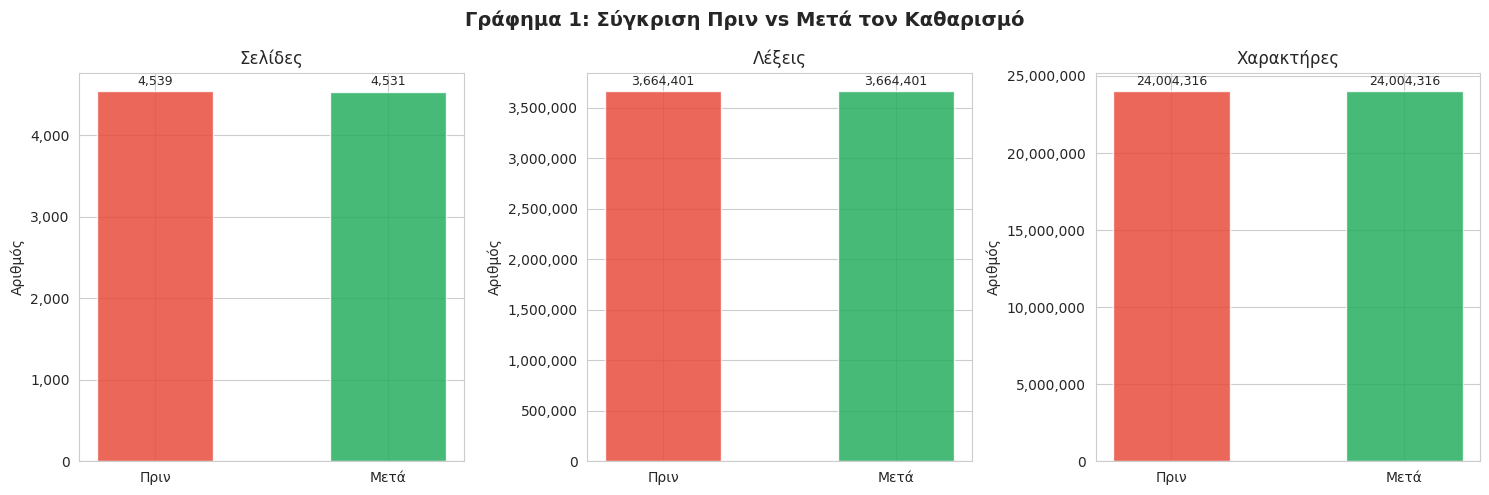

✅ Γράφημα 1 αποθηκεύτηκε: chart1_before_after.png
ℹ️  Δεν βρέθηκαν URLs για αφαίρεση — Γράφημα 2 παραλείπεται.


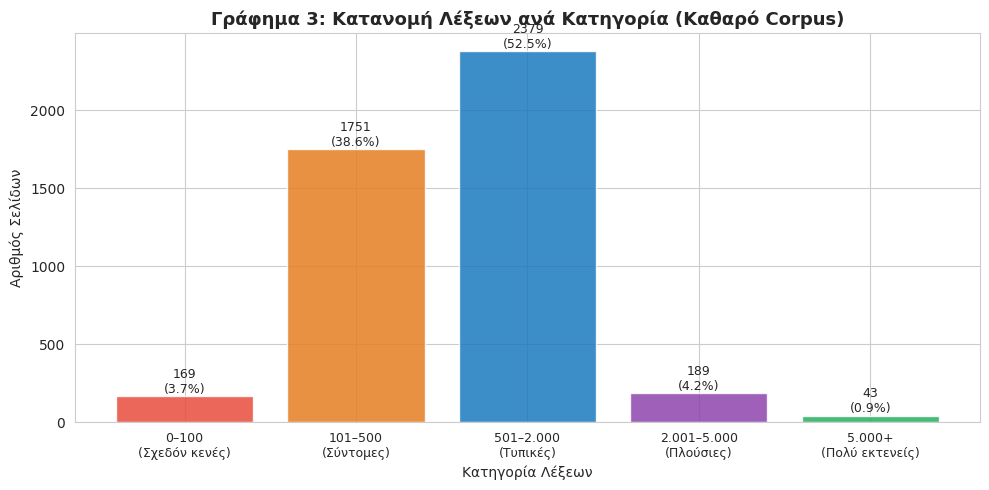

✅ Γράφημα 3 αποθηκεύτηκε: chart3_word_distribution.png

📋 ΣΥΓΚΕΝΤΡΩΤΙΚΑ ΣΤΑΤΙΣΤΙΚΑ PREPROCESSING A
Σελίδες πριν τον καθαρισμό :    4,539
Σελίδες μετά τον καθαρισμό :    4,531
Αφαιρεθέντα σύνολο         :        8  (0.2%)
Συνολικές λέξεις (clean)   : 3,664,401
Μέσος λέξεων / σελίδα      :    808.7
Διάμεσος λέξεων / σελίδα   :    595.0

🗂️  Κατανομή Λέξεων:
  0–100           :   169 σελίδες  (3.7%)
  101–500         :  1751 σελίδες  (38.6%)
  501–2.000       :  2379 σελίδες  (52.5%)
  2.001–5.000     :   189 σελίδες  (4.2%)
  5.000+          :    43 σελίδες  (0.9%)


In [ ]:
# ── Cell 8: Στατιστικά Καθαρισμού — Γραφήματα ────────────────────────

sns.set_style('whitegrid')
BLUE  = '#1a7abf'
GREEN = '#27ae60'
RED   = '#e74c3c'

# ════════════════════════════════════════════════════════════════════
# Γράφημα 1: Σύγκριση Πριν vs Μετά
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Γράφημα 1: Σύγκριση Πριν vs Μετά τον Καθαρισμό', fontsize=14, fontweight='bold')

metrics = [
    ('Σελίδες',     len(raw_df),                 len(clean_df)),
    ('Λέξεις',      raw_df['word_count'].sum(),   clean_df['word_count'].sum()),
    ('Χαρακτήρες',  raw_df['char_count'].sum(),   clean_df['char_count'].sum()),
]

for ax, (label, before, after) in zip(axes, metrics):
    bars = ax.bar(['Πριν', 'Μετά'], [before, after], color=[RED, GREEN], alpha=0.85, width=0.5)
    ax.set_title(label, fontsize=12)
    ax.set_ylabel('Αριθμός')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('chart1_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Γράφημα 1 αποθηκεύτηκε: chart1_before_after.png')

# ════════════════════════════════════════════════════════════════════
# Γράφημα 2: Ανάλυση αφαιρεθέντων URLs ανά τύπο
# ════════════════════════════════════════════════════════════════════
removal_data = removed_df['removal_reason'].value_counts()

if len(removal_data) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(removal_data) * 0.8)))
    colors = plt.cm.Reds_r([i / len(removal_data) for i in range(len(removal_data))])
    bars = ax.barh(removal_data.index, removal_data.values, color=colors, alpha=0.85)
    ax.set_xlabel('Πλήθος URLs')
    ax.set_title('Γράφημα 2: Αφαιρεθέντα URLs ανά Τύπο', fontsize=13, fontweight='bold')
    for bar, val in zip(bars, removal_data.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('chart2_removed_types.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Γράφημα 2 αποθηκεύτηκε: chart2_removed_types.png')
else:
    print('ℹ️  Δεν βρέθηκαν URLs για αφαίρεση — Γράφημα 2 παραλείπεται.')

# ════════════════════════════════════════════════════════════════════
# Γράφημα 3: Κατανομή αριθμού λέξεων σε κατηγορίες
# ════════════════════════════════════════════════════════════════════
bins   = [0, 100, 500, 2000, 5000, float('inf')]
labels = ['0–100', '101–500', '501–2.000', '2.001–5.000', '5.000+']

clean_df['word_category'] = pd.cut(
    clean_df['word_count'], bins=bins, labels=labels, right=True
)

cat_counts = clean_df['word_category'].value_counts().reindex(labels, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
palette = [RED, '#e67e22', BLUE, '#8e44ad', GREEN]
bars = ax.bar(cat_counts.index, cat_counts.values, color=palette, alpha=0.85, edgecolor='white')

ax.set_xlabel('Κατηγορία Λέξεων')
ax.set_ylabel('Αριθμός Σελίδων')
ax.set_title('Γράφημα 3: Κατανομή Λέξεων ανά Κατηγορία (Καθαρό Corpus)', fontsize=13, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    if height > 0:
        pct = height / len(clean_df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
                f'{height}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Επεξήγηση κατηγοριών
descriptions = [
    'Σχεδόν κενές', 'Σύντομες', 'Τυπικές', 'Πλούσιες', 'Πολύ εκτενείς'
]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([f'{l}\n({d})' for l, d in zip(labels, descriptions)], fontsize=9)

plt.tight_layout()
plt.savefig('chart3_word_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Γράφημα 3 αποθηκεύτηκε: chart3_word_distribution.png')

# ── Τελικά Στατιστικά ──
print('\n' + '='*55)
print('📋 ΣΥΓΚΕΝΤΡΩΤΙΚΑ ΣΤΑΤΙΣΤΙΚΑ PREPROCESSING A')
print('='*55)
print(f'Σελίδες πριν τον καθαρισμό : {total_raw:>8,}')
print(f'Σελίδες μετά τον καθαρισμό : {len(clean_df):>8,}')
print(f'Αφαιρεθέντα σύνολο         : {total_raw - len(clean_df):>8,}  ({(total_raw-len(clean_df))/total_raw*100:.1f}%)')
print(f'Συνολικές λέξεις (clean)   : {clean_df["word_count"].sum():>8,}')
print(f'Μέσος λέξεων / σελίδα      : {clean_df["word_count"].mean():>8.1f}')
print(f'Διάμεσος λέξεων / σελίδα   : {clean_df["word_count"].median():>8.1f}')
print('='*55)
print('\n🗂️  Κατανομή Λέξεων:')
for cat, cnt in cat_counts.items():
    pct = cnt / len(clean_df) * 100 if len(clean_df) > 0 else 0
    print(f'  {cat:<15} : {cnt:>5} σελίδες  ({pct:.1f}%)')